# 🌿 03 · EDA narrado: la historia de los datos

Este es el notebook **estrella**. Aquí ya no preparamos datos: los **interrogamos** para contar una historia,
apoyándonos en gráficos y en teoría estadística explicada al momento.

La historia sigue dos hilos:
- 🧪 **Químico-medicinal** — potencia (THC/CBD), efectos y usos terapéuticos.
- 💰 **Mercado** — qué determina el precio de una cepa.

Cada sección arranca con una **pregunta**, la responde con datos y cierra con una **interpretación**.

> 🧠 **Cómo leer este notebook:** las cajas con 🧠 explican el concepto estadístico que se usa justo después.
> Si ya lo dominas, puedes saltarlas; si no, te dan justo lo necesario para entender el gráfico.

---
## Preparación

Gracias a la limpieza del notebook `02`, cargar los datos listos es **una sola línea**: `clean(load_raw())`.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loading import load_raw, clean, explode_multi
from src.viz import set_style, save_fig, PALETTE, TYPE_COLORS

set_style()   # aplica el estilo visual del proyecto a todos los gráficos

df = clean(load_raw())
print("Datos listos:", df.shape)

Datos listos: (8910, 47)


# Parte 1 · Perfil químico 🧪

Empezamos por lo que más conecta con la biomedicina: **la composición química**. El THC es el compuesto
psicoactivo (el "efecto"); el CBD es el no psicoactivo, asociado a usos terapéuticos (dolor, ansiedad,
inflamación). Cuatro preguntas guían esta parte:

1. ¿Cómo de potentes son las cepas? (distribución del THC)
2. ¿Cuánto CBD tienen? (distribución del CBD)
3. ¿Cambia la potencia según el tipo (Indica/Sativa/Híbrido)?
4. ¿THC y CBD van de la mano?

## 1. ¿Cómo de potentes son las cepas?

> 🧠 **Distribución.** Una *distribución* muestra cómo se reparten los valores: qué valores son comunes y
> cuáles raros. El **histograma** es la forma clásica de verla: parte el rango en "cajones" (bins) y cuenta
> cuántas cepas caen en cada uno. La altura de cada barra = cuántas cepas tienen ese nivel de THC.
>
> Marcamos dos medidas de "centro":
> - **Media** (promedio): suma todo y divide. Sensible a valores extremos.
> - **Mediana**: el valor del medio si ordenas todos los datos. Robusta frente a extremos.
>
> Si la **media y la mediana casi coinciden**, la distribución es simétrica. Si la media es mayor que la
> mediana, hay una "cola" hacia la derecha (**sesgo positivo**): unos pocos valores altos la estiran.

Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\01_distribucion_thc.png


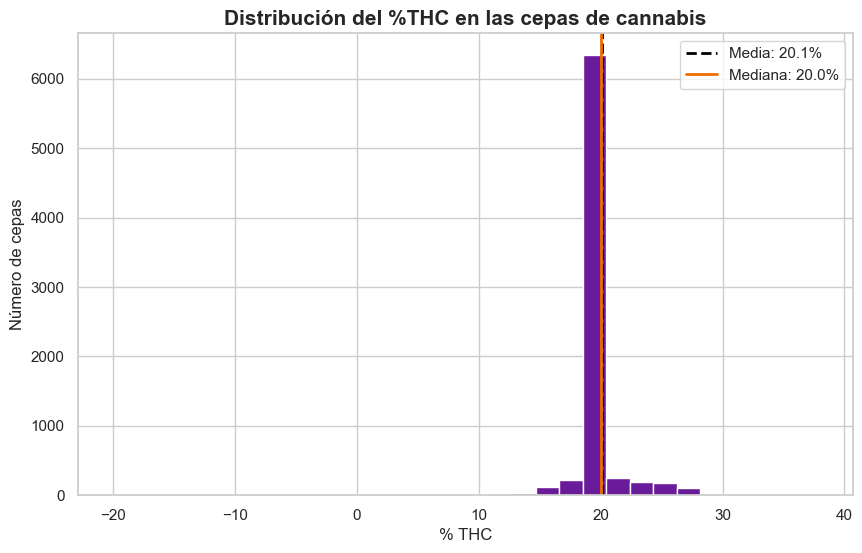

In [2]:
media_thc = df["thc_pct"].mean()
mediana_thc = df["thc_pct"].median()

fig, ax = plt.subplots()
ax.hist(df["thc_pct"], bins=30, color=PALETTE["purple"], edgecolor="white")
# Líneas verticales para media y mediana
ax.axvline(media_thc, color="black", linestyle="--", linewidth=2, label=f"Media: {media_thc:.1f}%")
ax.axvline(mediana_thc, color=PALETTE["orange"], linestyle="-", linewidth=2, label=f"Mediana: {mediana_thc:.1f}%")

ax.set_title("Distribución del %THC en las cepas de cannabis")
ax.set_xlabel("% THC")
ax.set_ylabel("Número de cepas")
ax.legend()
save_fig("01_distribucion_thc")
plt.show()

**¡Alto! Algo huele raro.** El histograma no parece una distribución natural: es **una sola barra gigante**
en 20%. Eso no pasa en datos reales de miles de cepas distintas. Cuando un gráfico se ve "demasiado
perfecto", hay que **desconfiar e investigar**. Contemos los valores exactos de THC:

In [3]:
# ¿Qué valores de THC son los más frecuentes?
print(df["thc_pct"].value_counts().head(5))

pct_en_20 = (df["thc_pct"] == 20.0).mean() * 100
print(f"\n% de cepas con THC == 20.0 exacto: {pct_en_20:.0f}%")
print(f"Valor mínimo de THC: {df['thc_pct'].min()}   <- ¡ojo, un % no puede ser negativo!")

# Muchas cepas no traían un número, sino una palabra ('High', 'Very High'), que quedó como NaN
n_texto = df["thc_pct"].isna().sum()
print(f"Cepas cuyo THC era texto y no número (High, Very High...): {n_texto}")

thc_pct
20.0    6151
18.0     120
19.0     104
22.0      96
25.0      92
Name: count, dtype: int64

% de cepas con THC == 20.0 exacto: 69%
Valor mínimo de THC: -20.0   <- ¡ojo, un % no puede ser negativo!
Cepas cuyo THC era texto y no número (High, Very High...): 1343


**Interpretación (el hallazgo real).** 🚨 El **69% de las cepas tiene THC = 20,0% exacto**. Eso no es una
coincidencia biológica: es un **valor por defecto** que el scraper puso cuando no encontró el dato real
(exactamente el mismo patrón que veremos con el efecto `Relaxing`). Y hay más basura escondida:
- un THC de **−20%**, **físicamente imposible** (un porcentaje no puede ser negativo);
- un **15%** de cepas cuyo THC no era un número sino una **palabra** (`High`, `Very High`).

**En total, solo ~16% de las cepas (1.415) tiene un THC numérico y creíble.** La columna es **poco confiable**:
cualquier "promedio de THC" estaría dominado por ese 20% inventado. De aquí en adelante, cuando analicemos
THC lo haremos con cuidado, usando solo las cepas con valores reales.

> 💡 **Esta es la lección más valiosa del notebook:** un analista mediocre habría reportado "las cepas tienen
> ~20% de THC en promedio" y habría quedado como un dato bonito pero **falso**. Detectar datos imputados
> *antes* de sacar conclusiones es lo que distingue el trabajo serio. En tu portafolio, esto vale oro.

## 2. ¿Cuánto CBD tienen?

Con la lección del THC fresca, ahora **desconfiamos primero**. Antes de graficar, miremos qué trae de verdad
la columna CBD original:

In [4]:
from src.data_loading import load_raw as _raw
cbd_crudo = _raw()["cbd"]
print(cbd_crudo.value_counts().head(6))
print(f"\n% de cepas cuyo CBD es la palabra 'Low': {(cbd_crudo == 'Low').mean()*100:.0f}%")
print(f"Cepas con CBD numérico (un número real): {df['cbd_pct'].notna().sum()} de {len(df)}")

cbd
Low       7477
Medium     126
0.1%        60
0.5%        49
0.8%        46
0.2%        43
Name: count, dtype: int64

% de cepas cuyo CBD es la palabra 'Low': 84%
Cepas con CBD numérico (un número real): 878 de 8910


**Ojo.** El CBD es todavía **peor** que el THC: el **84% de las cepas simplemente dice `"Low"`** (una
categoría, no un número), y solo **~10% (878 cepas)** tiene un valor numérico. Así que el histograma de abajo
representa solo a ese 10%. Aun así, es informativo — y, de hecho, la propia etiqueta `"Low"` ya nos adelanta
la conclusión: **el CBD es bajo en casi todo el catálogo.**

Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\02_distribucion_cbd.png


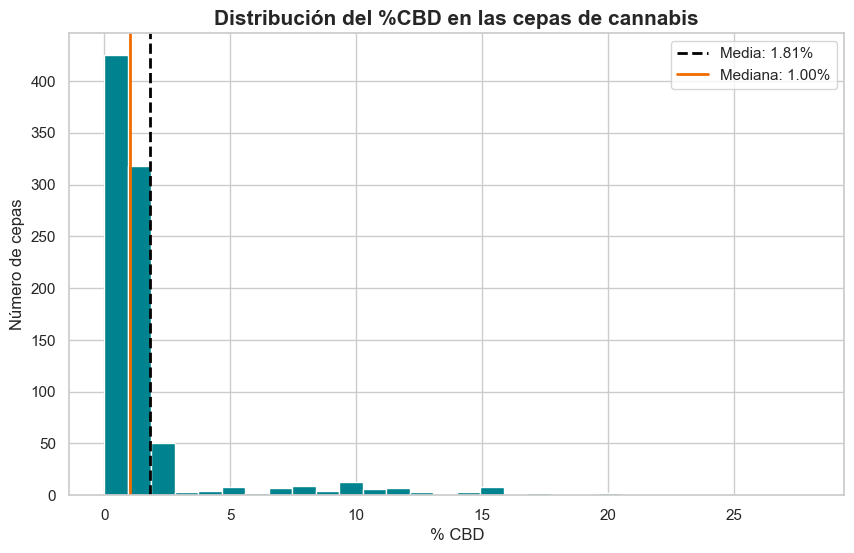

In [5]:
media_cbd = df["cbd_pct"].mean()
mediana_cbd = df["cbd_pct"].median()

fig, ax = plt.subplots()
ax.hist(df["cbd_pct"], bins=30, color=PALETTE["teal"], edgecolor="white")
ax.axvline(media_cbd, color="black", linestyle="--", linewidth=2, label=f"Media: {media_cbd:.2f}%")
ax.axvline(mediana_cbd, color=PALETTE["orange"], linestyle="-", linewidth=2, label=f"Mediana: {mediana_cbd:.2f}%")

ax.set_title("Distribución del %CBD en las cepas de cannabis")
ax.set_xlabel("% CBD")
ax.set_ylabel("Número de cepas")
ax.legend()
save_fig("02_distribucion_cbd")
plt.show()

**Interpretación.** Entre el 10% de cepas con CBD numérico, vemos un **sesgo positivo** claro: casi todas
tienen CBD muy bajo (1–2%), con una cola de pocas que llegan más alto. Fíjate en la pista estadística del
gráfico: la **media (1,81%) es mayor que la mediana (1,00%)**, justo la firma de una distribución con cola a
la derecha. Y coincide con lo que ya decían las etiquetas `"Low"` del 84% restante: **este catálogo está
pensado para el efecto psicoactivo (THC), no para uso terapéutico (CBD).** Dos fuentes distintas, misma
conclusión — eso da confianza.

> 💡 **Lección práctica:** cuando media > mediana, sospecha de una cola a la derecha. Ese detalle, que aquí
> confirmamos con el gráfico, es algo que un buen analista *nota solo con los números*.

## 3. ¿Cambia la potencia según el tipo de cepa?

Comparamos el THC de Indica, Sativa e Híbrido. Para comparar **grupos** la herramienta ideal es el
**boxplot** (diagrama de caja).

> 🧠 **Cómo leer un boxplot.** Cada caja resume un grupo:
> - La **línea dentro de la caja** = la mediana.
> - La **caja** va del primer cuartil (Q1, el 25% más bajo) al tercero (Q3, el 75%). Su alto se llama
>   **rango intercuartílico (IQR)** y mide la "dispersión" del grueso de los datos.
> - Los **bigotes** llegan hasta los valores aún "normales"; los **puntos sueltos** son *outliers*
>   (valores atípicos, inusualmente altos o bajos).
>
> Comparar cajas nos dice de un vistazo si un grupo es más potente (caja más arriba) o más variable
> (caja más alta) que otro.

Cepas con THC real y posible: 1415 de 8910 (16%)


Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\03_thc_por_tipo.png


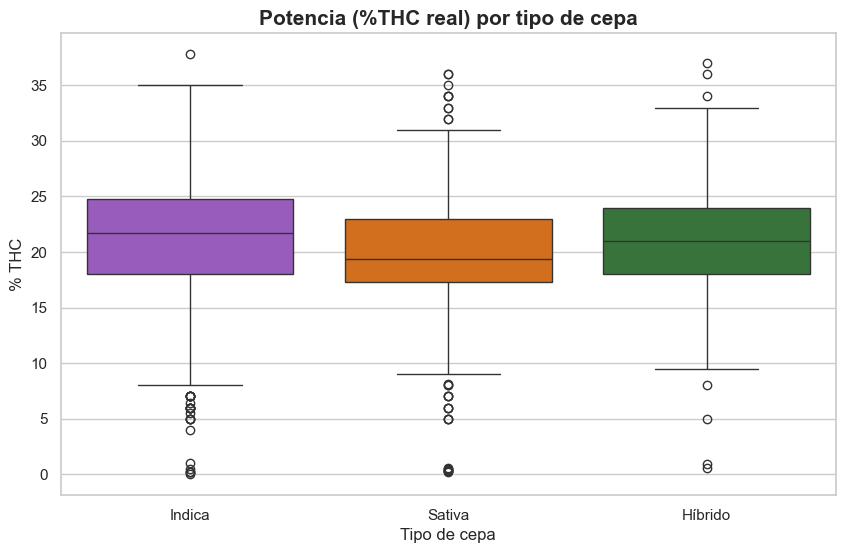

Mediana de THC real por tipo:
type_simple
Híbrido    21.0
Indica     21.7
Sativa     19.4
Name: thc_pct, dtype: float64


In [6]:
orden = ["Indica", "Sativa", "Híbrido"]

# Analizamos SOLO el THC real: quitamos el 20% por defecto y los valores imposibles (fuera de 0-100%).
# Si usáramos todos los datos, el 69% "pegado" en 20% aplastaría cualquier diferencia entre tipos.
df_real_thc = df[(df["thc_pct"] != 20.0) & (df["thc_pct"].between(0, 100))]
print(f"Cepas con THC real y posible: {len(df_real_thc)} de {len(df)} ({len(df_real_thc)/len(df)*100:.0f}%)")

fig, ax = plt.subplots()
sns.boxplot(
    data=df_real_thc, x="type_simple", y="thc_pct",
    order=orden, hue="type_simple", hue_order=orden,
    palette=TYPE_COLORS, legend=False, ax=ax,
)
ax.set_title("Potencia (%THC real) por tipo de cepa")
ax.set_xlabel("Tipo de cepa")
ax.set_ylabel("% THC")
save_fig("03_thc_por_tipo")
plt.show()

print("Mediana de THC real por tipo:")
print(df_real_thc.groupby("type_simple")["thc_pct"].median().round(1))

**Interpretación.** Al mirar solo el THC **real** (~16% de cepas con dato fiable), aparece una diferencia
que el valor por defecto escondía: la **Indica** es ligeramente más potente (mediana ~21,7%), la **Sativa**
algo menos (~19,4%) y el **Híbrido** queda en medio (~21%). Es un guiño a la creencia popular de que "las
Indicas pegan más"... pero **ojo**: la diferencia es **pequeña** (2 puntos de mediana) y las cajas se solapan
bastante. Conclusión honesta: *hay una tendencia leve, no una regla*. Y aún así se apoya solo en ~1 de cada 6
cepas, así que la tomamos con pinzas.

## 4. ¿THC y CBD van de la mano?

Última pregunta química: ¿las cepas con más THC tienen también más CBD, o es al revés? Para relacionar
**dos variables numéricas** usamos un **gráfico de dispersión** (scatter): cada punto es una cepa, ubicada
según su THC (eje X) y su CBD (eje Y).

> 🧠 **Correlación.** El coeficiente de correlación de Pearson (*r*) resume esa relación en un número entre
> −1 y +1:
> - **+1**: cuando una sube, la otra sube (relación positiva perfecta).
> - **−1**: cuando una sube, la otra baja (negativa perfecta).
> - **0**: no hay relación lineal.
>
> ⚠️ **Correlación no es causalidad.** Que dos cosas se muevan juntas no significa que una *cause* la otra.

Correlación de Pearson (THC vs CBD): r = -0.69  (calculada sobre 701 cepas con ambos números)


Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\04_thc_vs_cbd.png


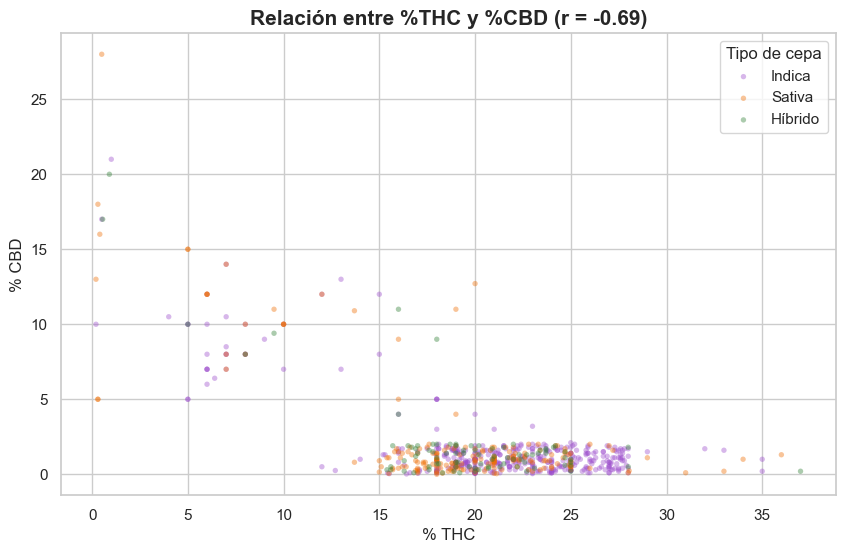

In [7]:
r = df["thc_pct"].corr(df["cbd_pct"])
n_pares = df[["thc_pct", "cbd_pct"]].dropna().shape[0]
print(f"Correlación de Pearson (THC vs CBD): r = {r:.2f}  (calculada sobre {n_pares} cepas con ambos números)")

fig, ax = plt.subplots()
# Un color por tipo, para ver si algún grupo se comporta distinto
for tipo in orden:
    subset = df[df["type_simple"] == tipo]
    ax.scatter(
        subset["thc_pct"], subset["cbd_pct"],
        color=TYPE_COLORS[tipo], label=tipo,
        alpha=0.4, s=15, edgecolors="none",
    )
ax.set_title(f"Relación entre %THC y %CBD (r = {r:.2f})")
ax.set_xlabel("% THC")
ax.set_ylabel("% CBD")
ax.legend(title="Tipo de cepa")
save_fig("04_thc_vs_cbd")
plt.show()

**Interpretación.** La correlación es **moderada y negativa** (r = −0,69): cuando una sube, la otra tiende
a bajar. El scatter muestra por qué se forman **dos grupos**: uno arriba a la derecha —THC alto y CBD casi
cero— y otro a la izquierda —THC bajo y CBD más alto (5–28%)—. Es decir, las cepas suelen ser "de THC" **o**
"de CBD", rara vez las dos cosas. Encaja con la biología: ambos compuestos compiten por el mismo precursor
químico en la planta, así que favorecer uno tiende a reducir el otro. La relación **se mantiene** aunque
quitemos el valor por defecto (r sigue ≈ −0,70), así que es **real**, no un artefacto. Eso sí: se calcula
sobre solo **701 cepas** (las que tienen THC y CBD numéricos a la vez), así que es una muestra modesta.

> ⚠️ **Correlación no es causalidad.** Que THC y CBD se muevan en direcciones opuestas no significa que uno
> "cause" la bajada del otro: comparten una causa común (la bioquímica de la planta). Confundir correlación
> con causalidad es uno de los errores más típicos —y peligrosos— al analizar datos.

---
### 📝 Resumen de la Parte 1 (Perfil químico)

- ⚠️ **El THC es poco confiable:** el 69% vale 20% exacto (valor por defecto del scraper) y hay valores
  imposibles (negativos). *Detectar esto es el hallazgo más importante de la sección.*
- El **CBD sí es confiable:** bajo en casi todas, con **sesgo positivo** (cola a la derecha). Catálogo
  claramente orientado al THC, no al uso terapéutico.
- Con el **THC real** (31% de cepas), la Indica es levemente más potente que la Sativa: una **tendencia
  leve**, no una regla.
- THC y CBD tienen una correlación **moderada y negativa** (r ≈ −0,69), real y explicable por la biología.
  Pero **correlación no es causalidad**.

**Siguiente (Parte 2):** efectos y usos medicinales — e investigamos el sospechoso efecto `Relaxing` que
detectamos en la limpieza (mismo patrón de valor por defecto que acabamos de ver con el THC).

# Parte 2 · Efectos y usos medicinales 💫

Aquí analizamos qué **sensaciones** producen las cepas (`effect`) y para qué **condiciones** se usan
(`medical_strains`). Son columnas *multi-etiqueta* (varias por celda, separadas por comas), así que las
**explotamos** para contar. Tres preguntas:

1. ¿Cuál es el efecto más común? (con la lección del THC, desconfiamos primero)
2. ¿Qué usos medicinales destacan?
3. ¿El patrón de "valor por defecto" se repite en más columnas?

## 1. ¿Cuál es el efecto más común?

> 🧠 **Gráfico de barras horizontales.** Para comparar la **frecuencia de categorías** (aquí, efectos), las
> barras son ideales: la longitud representa el conteo. Las ponemos horizontales para que las etiquetas de
> texto se lean cómodas.

Pero antes de graficar, ya sabemos que hay que desconfiar. Miremos el valor crudo más frecuente de `effect`:

In [8]:
print(df["effect"].value_counts().head(4))
print(f"\n% de cepas cuyo effect es EXACTAMENTE 'Relaxing': {(df['effect']=='Relaxing').mean()*100:.0f}%")

effect
Relaxing    6752
Euphoric      48
Relaxed       43
Creative      36
Name: count, dtype: int64

% de cepas cuyo effect es EXACTAMENTE 'Relaxing': 76%


**Lo esperábamos:** el **76%** de las cepas dice solo `Relaxing`. Es el **mismo truco del THC=20%**: un
valor por defecto. Si graficáramos tal cual, "Relaxing" aplastaría todo y el gráfico no diría nada.

La solución: **quitar las cepas que solo traen el default** y explotar el resto para ver los efectos que
*realmente* se reportan de forma variada.

Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\05_top_efectos.png


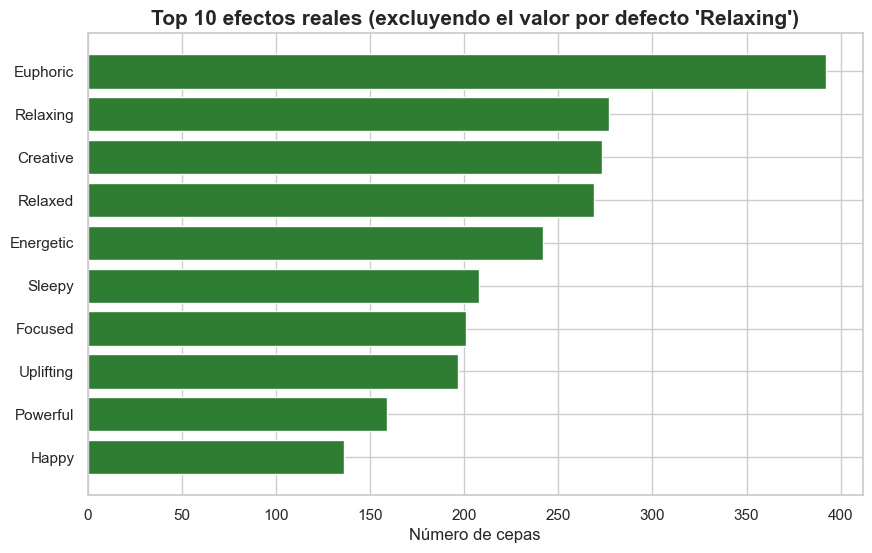

In [9]:
# Excluimos las cepas cuyo effect es solo el valor por defecto, y explotamos el resto
efectos_reales = explode_multi(df[df["effect"] != "Relaxing"], "effect")
top_efectos = efectos_reales.value_counts().head(10)

fig, ax = plt.subplots()
# [::-1] invierte el orden para que la barra más larga quede arriba
ax.barh(top_efectos.index[::-1], top_efectos.values[::-1], color=PALETTE["green"])
ax.set_title("Top 10 efectos reales (excluyendo el valor por defecto 'Relaxing')")
ax.set_xlabel("Número de cepas")
save_fig("05_top_efectos")
plt.show()

**Interpretación.** Ya sin el ruido del default, aparece un abanico con sentido: **Euphoric** (eufórico),
**Creative** (creativo), **Energetic** (energético), **Sleepy** (somnoliento), **Focused** (concentrado)...
Fíjate que conviven efectos opuestos: unos energizantes (Energetic, Creative, Focused) y otros sedantes
(Sleepy, Relaxed, Calming). Eso refleja la variedad real del catálogo: hay cepas para "activarse" y cepas
para "apagarse". *Esto sí es información útil* — y solo se ve tras limpiar el default.

## 2. ¿Qué usos medicinales destacan?

Repetimos con `medical_strains`. Esta columna es la que más conecta con la **biomedicina**: dice para qué
condiciones se recomienda cada cepa. También tiene `Relaxing` como default (~52%), así que lo excluimos igual.

Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\06_usos_medicinales.png


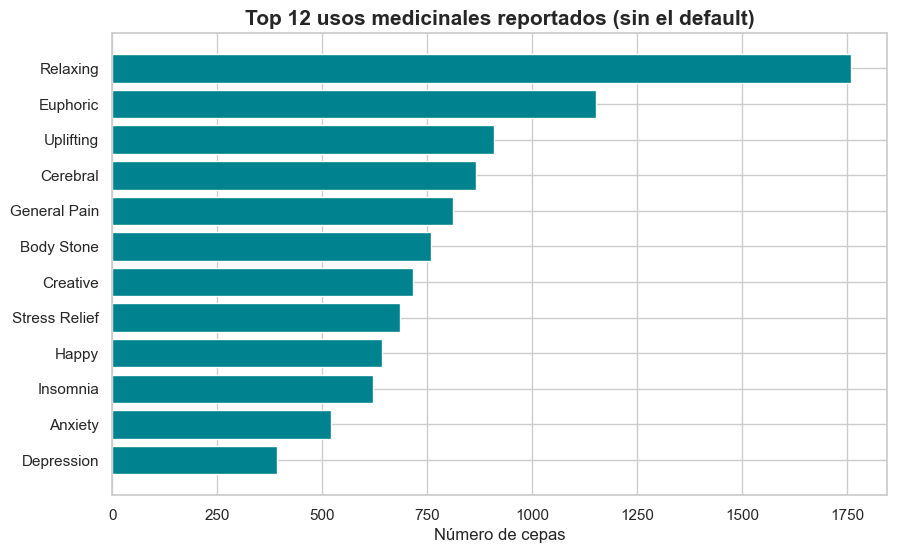

In [10]:
usos = explode_multi(df[df["medical_strains"] != "Relaxing"], "medical_strains")
top_usos = usos.value_counts().head(12)

fig, ax = plt.subplots()
ax.barh(top_usos.index[::-1], top_usos.values[::-1], color=PALETTE["teal"])
ax.set_title("Top 12 usos medicinales reportados (sin el default)")
ax.set_xlabel("Número de cepas")
save_fig("06_usos_medicinales")
plt.show()

**Interpretación.** Entre los términos hay dos grupos. Unos son más bien *efectos* que se colaron
(Euphoric, Uplifting, Cerebral, Happy). Pero otros son **condiciones clínicas de verdad**, y son las
interesantes desde la biomedicina:

- **General Pain** (dolor general) — 810 cepas
- **Stress Relief** (alivio del estrés) — 686
- **Insomnia** — 621
- **Anxiety** (ansiedad) — 521
- **Depression** (depresión) — 391

Encaja con la literatura: el cannabis medicinal se asocia sobre todo a **dolor, insomnio y ansiedad**. Es un
buen puente hacia tu carrera: aquí los datos comerciales tocan aplicaciones terapéuticas reales.

## 3. El hallazgo transversal: los valores por defecto están en TODAS partes

Hemos visto el mismo truco en THC, CBD y efectos. ¿Y si es un patrón general del scraper? Comprobémoslo
midiendo, en cada columna clave, **qué porcentaje son un único valor por defecto**.

Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\07_valores_por_defecto.png


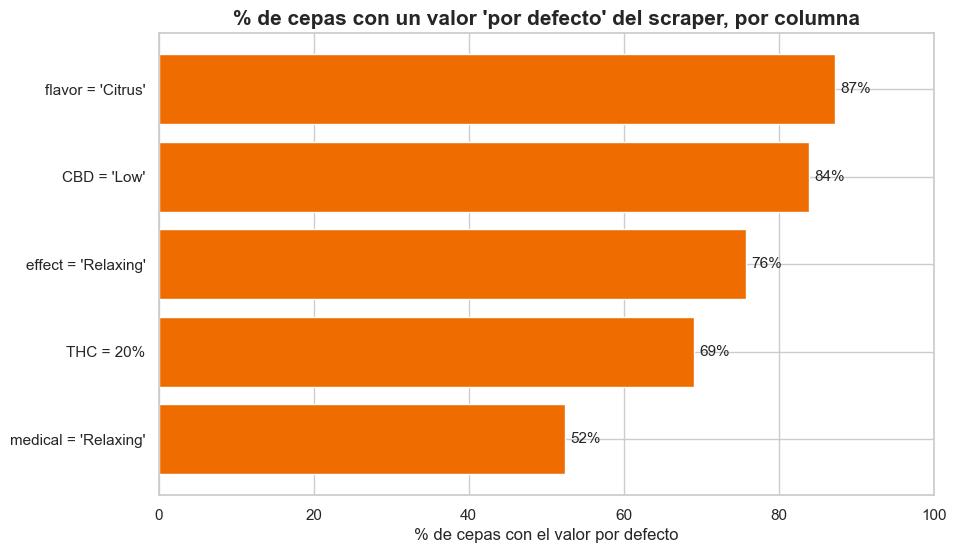

In [11]:
raw = load_raw()   # necesitamos los valores crudos de cbd y flavor (texto)

defaults = {
    "THC = 20%": (df["thc_pct"] == 20.0).mean() * 100,
    "CBD = 'Low'": (raw["cbd"] == "Low").mean() * 100,
    "effect = 'Relaxing'": (df["effect"] == "Relaxing").mean() * 100,
    "medical = 'Relaxing'": (df["medical_strains"] == "Relaxing").mean() * 100,
    "flavor = 'Citrus'": (raw["flavor"] == "Citrus").mean() * 100,
}
serie = pd.Series(defaults).sort_values()

fig, ax = plt.subplots()
barras = ax.barh(serie.index, serie.values, color=PALETTE["orange"])
ax.bar_label(barras, fmt="%.0f%%", padding=4)   # etiqueta con el % al final de cada barra
ax.set_title("% de cepas con un valor 'por defecto' del scraper, por columna")
ax.set_xlabel("% de cepas con el valor por defecto")
ax.set_xlim(0, 100)
save_fig("07_valores_por_defecto")
plt.show()

**Interpretación (el meta-hallazgo).** 🎯 Entre el **52% y el 87%** de las cepas traen un valor por defecto
en cada columna clave. No es un error puntual: es la **firma del scraper**, que rellenó con un valor genérico
todo lo que no pudo extraer.

Esto tiene una consecuencia importantísima para cualquiera que use este dataset: **la mayoría de los "datos"
químicos y de efectos son relleno.** El análisis serio consiste en *separar la señal del relleno* — justo lo
que hicimos. Un informe que ignore esto estaría construido sobre arena.

---
### 📝 Resumen de la Parte 2 (Efectos y usos medicinales)

- El efecto `Relaxing` es un **valor por defecto** (76%); tras quitarlo, los efectos reales se reparten entre
  **energizantes** (Euphoric, Creative, Energetic) y **sedantes** (Sleepy, Relaxed, Calming).
- Los usos medicinales reales más frecuentes son **dolor, estrés, insomnio, ansiedad y depresión** — coherente
  con la evidencia sobre cannabis terapéutico.
- **Meta-hallazgo:** los valores por defecto afectan al **52–87%** de cada columna clave. Es el patrón que
  define este dataset.

**Siguiente (Parte 3):** el ángulo de mercado — ¿qué determina el **precio** de una cepa?

# Parte 3 · Mercado y precios 💰

Cambiamos de sombrero: del laboratorio al negocio. Este es el ángulo que más habla el lenguaje de un cliente
de freelancing. Tres preguntas:

1. ¿Cuánto cuesta una cepa?
2. ¿La potencia (THC/CBD) explica el precio?
3. Si no es la química... ¿qué manda en el precio?

## 1. ¿Cuánto cuesta una cepa?

> 🧠 **Distribución sesgada y por qué la mediana gana.** Cuando unos pocos valores enormes conviven con
> muchos pequeños, la **media** se dispara y deja de representar al caso típico. La **mediana** (el valor del
> medio) aguanta mejor. En precios, ingresos o tiempos, la mediana casi siempre es más honesta.

count    8910.00
mean       82.39
std       166.57
min         0.00
25%         9.02
50%        19.00
75%        47.40
max       999.79
Name: current_price_gbp, dtype: float64

Cepas con precio <= GBP 100: 7456 de 8910 (84%)


Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\08_distribucion_precio.png


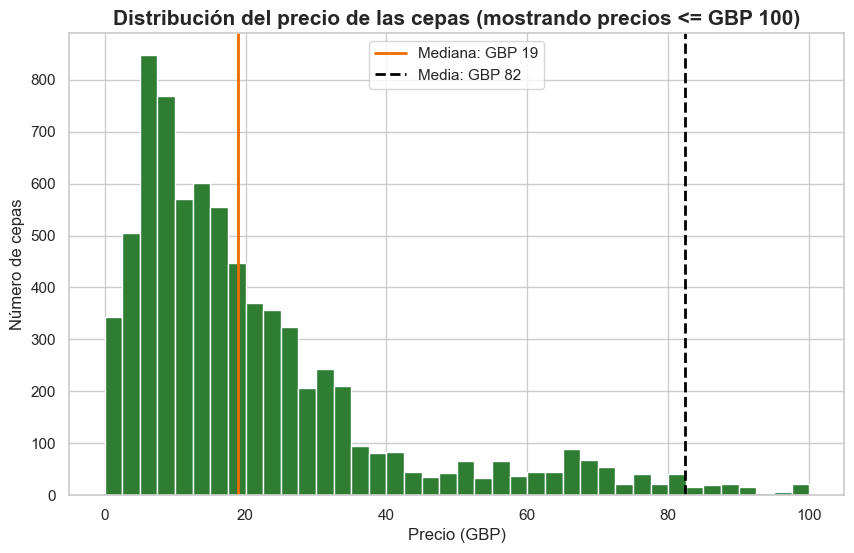

In [12]:
precio = df["current_price_gbp"]
print(precio.describe().round(2))

# El precio va de £0 a £999, pero la mayoría es barato. Para que el histograma se lea,
# mostramos solo los precios <= £100 (e indicamos qué porcentaje representa).
umbral = 100
bajo = precio[precio <= umbral]
print(f"\nCepas con precio <= GBP {umbral}: {len(bajo)} de {len(df)} ({len(bajo)/len(df)*100:.0f}%)")

fig, ax = plt.subplots()
ax.hist(bajo, bins=40, color=PALETTE["green"], edgecolor="white")
ax.axvline(precio.median(), color=PALETTE["orange"], linewidth=2, label=f"Mediana: GBP {precio.median():.0f}")
ax.axvline(precio.mean(), color="black", linestyle="--", linewidth=2, label=f"Media: GBP {precio.mean():.0f}")
ax.set_title("Distribución del precio de las cepas (mostrando precios <= GBP 100)")
ax.set_xlabel("Precio (GBP)")
ax.set_ylabel("Número de cepas")
ax.legend()
save_fig("08_distribucion_precio")
plt.show()

**Interpretación.** El precio está **fuertemente sesgado a la derecha**: la cepa típica cuesta unas
**£19** (mediana), pero la **media es £82** porque un puñado de cepas premium llega hasta **£999**. Aquí se ve
clarísimo por qué preferimos la mediana: decir "el precio promedio es £82" daría una idea equivocada del
mercado. La mayoría de los productos son **baratos**; los caros son la excepción que estira el promedio.

> 💡 **Dato de marketing:** además, el **97% de las cepas figura con un 40% de descuento**. No es que estén
> "de oferta": es una estrategia comercial permanente. Otro "valor casi constante", ahora en clave de negocio.

## 2. ¿La potencia explica el precio?

La hipótesis intuitiva: "más THC = más caro". La ponemos a prueba midiendo la correlación del precio con las
variables químicas. (Para el THC usamos el subconjunto real, no el valor por defecto.)

THC (real)      -0.18
CBD              0.24
Nº de efectos   -0.07
dtype: float64


Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\09_correlaciones_precio.png


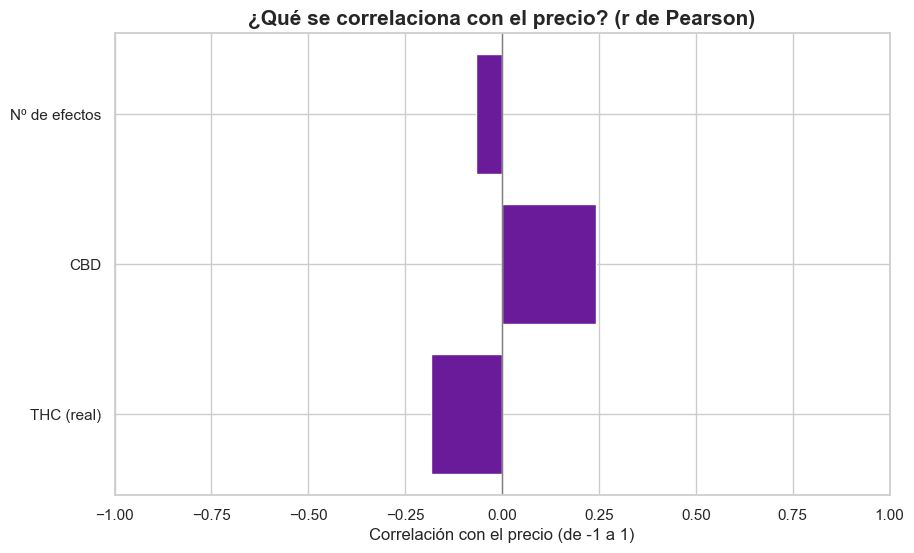

In [13]:
real = df[(df["thc_pct"] != 20.0) & (df["thc_pct"].between(0, 100))]

correlaciones = {
    "THC (real)": real["current_price_gbp"].corr(real["thc_pct"]),
    "CBD": df["current_price_gbp"].corr(df["cbd_pct"]),
    "Nº de efectos": df["current_price_gbp"].corr(df["num_effects"]),
}
serie = pd.Series(correlaciones)
print(serie.round(2))

fig, ax = plt.subplots()
ax.barh(list(serie.index), list(serie.values), color=PALETTE["purple"])
ax.axvline(0, color="gray", linewidth=1)   # línea en cero: a la derecha positivo, a la izquierda negativo
ax.set_title("¿Qué se correlaciona con el precio? (r de Pearson)")
ax.set_xlabel("Correlación con el precio (de -1 a 1)")
ax.set_xlim(-1, 1)
save_fig("09_correlaciones_precio")
plt.show()

**Interpretación.** Sorpresa (o no): **la química apenas explica el precio.** Todas las correlaciones están
cerca de cero (THC r ≈ −0,18, CBD r ≈ 0,24, nº de efectos ≈ 0). Es decir, *pagar más NO te garantiza una cepa
más potente*. La creencia "más caro = más fuerte" **no se sostiene** en estos datos. Entonces, ¿qué mueve el
precio? Lo vemos en la siguiente pregunta.

## 3. Si no es la química... ¿qué manda en el precio?

Probemos con el **breeder** (la marca que produce la semilla). En muchos mercados, la **marca** pesa más que
el producto en sí. Comparamos el precio medio de los breeders con más catálogo.

Gráfico guardado en C:\Users\león\Documents\VacacionesDiciembre2025IA\EDA\cannabis-eda-project\images\10_precio_por_breeder.png


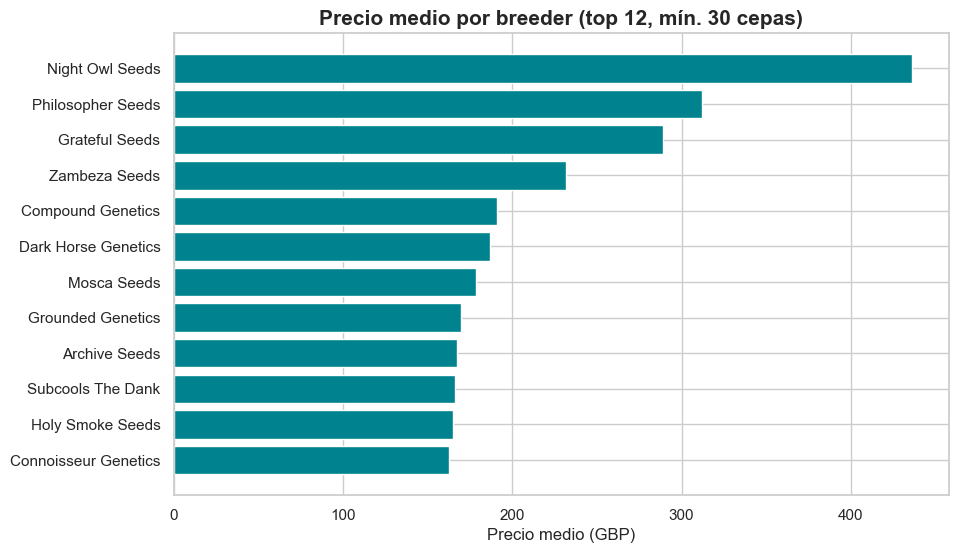

Breeder más caro:  Night Owl Seeds -> 436 GBP
Breeder más barato: Victory Seeds -> 11 GBP


In [14]:
# Precio medio por breeder, quedándonos con los que tienen al menos 30 cepas (para que sea representativo)
por_breeder = df.groupby("breeder")["current_price_gbp"].agg(["mean", "count"])
por_breeder = por_breeder[por_breeder["count"] >= 30].sort_values("mean", ascending=False)

top = por_breeder.head(12)
fig, ax = plt.subplots()
ax.barh(top.index[::-1], top["mean"].values[::-1], color=PALETTE["teal"])
ax.set_title("Precio medio por breeder (top 12, mín. 30 cepas)")
ax.set_xlabel("Precio medio (GBP)")
save_fig("10_precio_por_breeder")
plt.show()

print("Breeder más caro: ", por_breeder.index[0], "->", round(por_breeder['mean'].iloc[0]), "GBP")
print("Breeder más barato:", por_breeder.index[-1], "->", round(por_breeder['mean'].iloc[-1]), "GBP")

**Interpretación.** ¡Aquí sí hay señal! El precio medio va desde **~£11** (Victory Seeds) hasta **~£436**
(Night Owl Seeds): una diferencia de **casi 40 veces** según la marca. El **breeder explica el precio mucho
mejor que la potencia.** Traducido al negocio: *estás pagando por la marca y el prestigio del criador, no por
tener más THC*. Este es exactamente el tipo de conclusión accionable que un cliente valora — y que conecta el
dato con una decisión real de compra.

---
### 📝 Resumen de la Parte 3 (Mercado)

- El precio está **muy sesgado**: mediana **£19**, media £82, máximos de £999. La mediana es la medida honesta.
- El **97% figura con 40% de descuento**: estrategia comercial permanente, no ofertas reales.
- La **química (THC/CBD) casi no explica el precio** (correlaciones ≈ 0).
- El **breeder sí manda**: hasta 40× de diferencia. Pagas por la marca, no por la potencia.

# 🏁 Conclusiones generales del EDA

Juntando las tres partes, esta es la historia completa del dataset:

**Sobre los datos (calidad):**
- El dataset *parece* limpio (0% nulos) pero está **lleno de valores por defecto**: entre el 52% y el 87% de
  cada columna clave es relleno del scraper (THC=20%, CBD='Low', effect/medical='Relaxing', flavor='Citrus').
- Hay valores imposibles (THC negativo) y números guardados como texto.
- **Lección:** el trabajo de un analista es *separar la señal del relleno*. Reportar promedios sin verificar
  habría producido conclusiones falsas.

**Sobre las cepas (lo químico-medicinal):**
- El catálogo está orientado al **THC** (alto) y no al **CBD** (bajo en casi todas).
- El tipo Indica/Sativa/Híbrido apenas diferencia la potencia (tendencia leve: Indica algo más fuerte).
- Los usos medicinales reales más citados —**dolor, estrés, insomnio, ansiedad, depresión**— coinciden con la
  evidencia sobre cannabis terapéutico.

**Sobre el mercado (lo comercial):**
- Precios muy dispares (mediana £19, máx £999) con 40% de descuento casi universal.
- **El precio lo determina la marca (breeder), no la potencia.** Pagas por prestigio, no por química.

**En una frase:** *es un catálogo comercial de semillas de alta potencia y bajo CBD, con datos muy imputados,
donde el precio responde al prestigio de la marca más que a la calidad química declarada.*

---
_Análisis realizado por León · datos: JonusNattapong/cannabis-strains (Hugging Face) · código en `src/`._